In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install tensorflow opencv-python-headless numpy matplotlib

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import os

# Montar Google Drive (necesario para acceder a las imágenes subidas)
from google.colab import drive
drive.mount('/content/drive')

# Definir la ruta base (ajusta según donde subas las carpetas)
base_dir = '/content/drive/My Drive/stacion'

# Generadores de datos
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=[0.8, 1.2]
)

validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=(224, 224),  # Ajuste para VGG16
    batch_size=64,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    os.path.join(base_dir, 'validation'),
    target_size=(224, 224),
    batch_size=64,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(base_dir, 'test'),
    target_size=(224, 224),
    batch_size=64,
    class_mode='binary'
)

# Cargar VGG16 preentrenado
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Congelar capas base

# Crear modelo personalizado
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.6),  # Regularización
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')  # Clasificación binaria: dañado/no dañado
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# EarlyStopping para evitar sobreajuste
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# Entrenar el modelo
model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=[early_stopping]
)

# Evaluar el modelo
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Precisión en el conjunto de test: {test_accuracy*100:.2f}%")

# Guardar el modelo para usarlo después
# Guardar con el nuevo formato
model.save('/content/drive/My Drive/stacion/modelo_paneles_solares4.keras')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 882 images belonging to 2 classes.
Found 525 images belonging to 2 classes.
Found 545 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1009s 73s/step - accuracy: 0.4996 - loss: 1.0963 - val_accuracy: 0.5771 - val_loss: 0.6690
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 975s 72s/step - accuracy: 0.5606 - loss: 0.7486 - val_accuracy: 0.4762 - val_loss: 0.6678
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 969s 70s/step - accuracy: 0.6485 - loss: 0.6560 - val_accuracy: 0.7600 - val_loss: 0.6597
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 975s 72s/step - accuracy: 0.5731 - loss: 0.6669 - val_accuracy: 0.7619 - val_loss: 0.6391
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1006s 74s/step - accuracy: 0.6247 - loss: 0.6094 - val_accuracy: 0.7410 - val_loss: 0.5637
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1018s 75s/step - accuracy: 0.6786 - loss: 0.5862 - val_accuracy: 0.6990 - val_loss: 0.6180
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 946s 69s/step - accuracy: 0.6645 - loss: 0.5862 - val_accuracy: 0.7886 - val_loss: 0.6006
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1021s 72s/step - accuracy: 0.7195 - loss: 0.5845 - val_accuracy

In [ ]:
%%writefile "/content/drive/My Drive/stacion/app.py"
import tensorflow as tf
import numpy as np
from flask import Flask, request, render_template, jsonify
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import cv2
import os
import base64
from io import BytesIO
from PIL import Image

app = Flask(__name__)

# Cargar el modelo
model = tf.keras.models.load_model('/content/drive/My Drive/stacion/modelo_paneles_solares4.keras')

# Directorio para guardar imágenes temporales
UPLOAD_FOLDER = '/tmp/uploads'
os.makedirs(UPLOAD_FOLDER, exist_ok=True)

# Preprocesar imagen para la IA
def preprocess_image(image_path):
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

# Detectar y resaltar daño (áreas claras como agujeros)
def highlight_damage(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Detectar áreas claras (agujeros) con umbral
    _, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Calcular área de daño (aproximada)
    total_area = img.shape[0] * img.shape[1]
    damage_area = sum(cv2.contourArea(c) for c in contours)
    damage_percent = (damage_area / total_area) * 100 if total_area > 0 else 0

    # Dibujar contornos rojos
    cv2.drawContours(img_rgb, contours, -1, (255, 0, 0), 2)

    # Guardar imagen resaltada
    highlighted_path = os.path.join(UPLOAD_FOLDER, 'highlighted.jpg')
    cv2.imwrite(highlighted_path, cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))

    # Convertir a base64 para mostrar en web
    with open(highlighted_path, "rb") as img_file:
        img_base64 = base64.b64encode(img_file.read()).decode('utf-8')

    return img_base64, damage_percent

@app.route('/')
def index():
    return render_template('index.html')

@app.route('/predict', methods=['POST'])
def predict():
    if 'image' not in request.files:
        return jsonify({'error': 'No se subió ninguna imagen'})

    file = request.files['image']
    image_path = os.path.join(UPLOAD_FOLDER, 'uploaded.jpg')
    file.save(image_path)

    # Predecir con el modelo
    processed_image = preprocess_image(image_path)
    prediction = model.predict(processed_image)[0][0]
    result = 'Daño detectado' if prediction > 0.5 else 'Sin daños'
    confidence = prediction * 100 if prediction > 0.5 else (1 - prediction) * 100

    # Resaltar daño si es detectado
    highlighted_image, damage_percent = None, 0
    if prediction > 0.5:
        highlighted_image, damage_percent = highlight_damage(image_path)

    # Guardar predicción en CSV
    with open('/content/drive/My Drive/stacion/predictions.csv', 'a') as f:
        f.write(f"{image_path},{result},{confidence:.2f},{damage_percent:.2f}\n")

    return jsonify({
        'result': result,
        'confidence': f"{confidence:.2f}%",
        'damage_percent': f"{damage_percent:.2f}%" if damage_percent > 0 else "N/A",
        'highlighted_image': highlighted_image
    })

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000, debug=True)

Overwriting /content/drive/My Drive/stacion/app.py


In [ ]:
# Instalar dependencias
!pip install flask tensorflow opencv-python-headless pillow pyngrok


In [ ]:
# =====================================
# 🔧 Configuración inicial
# =====================================
# 1. Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Borrar configuraciones viejas de ngrok (importante)
!rm -rf /root/.ngrok2

# 3. Agregar tu nuevo token de ngrok
!ngrok config add-authtoken 33dI8FuPzwwNQOxi6bYksdcX8KK_2U3AbKc37x68XgFtsyM6p

# =====================================
# 🚀 Iniciar Flask + ngrok
# =====================================
from pyngrok import ngrok
import os
import time

# Cerrar túneles previos
ngrok.kill()

# Conectar al puerto 5000
public_url = ngrok.connect(5000)
print("🌐 Tu app está disponible en:", public_url)

# 4. Ejecutar tu aplicación Flask (ajusta la ruta si es distinta)
os.system('python "/content/drive/My Drive/stacion/app.py" &')

# Mantener la sesión activa
while True:
    time.sleep(10)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
🌐 Tu app está disponible en: NgrokTunnel: "https://8d68b7e2ff83.ngrok-free.app" -> "http://localhost:5000"


KeyboardInterrupt: 

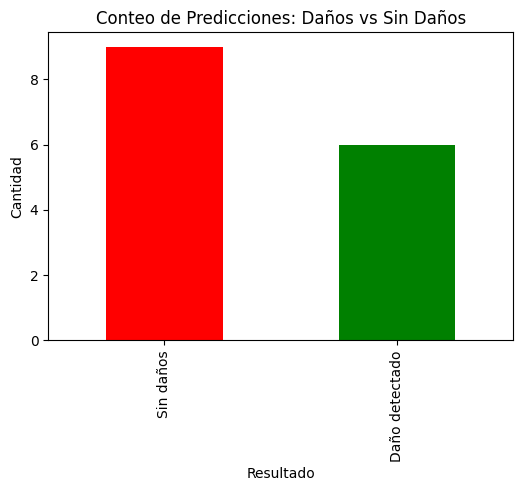

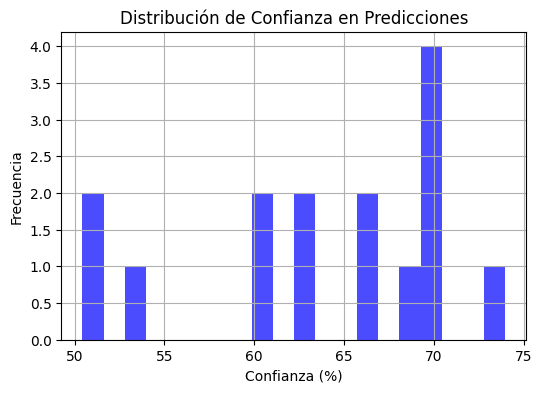

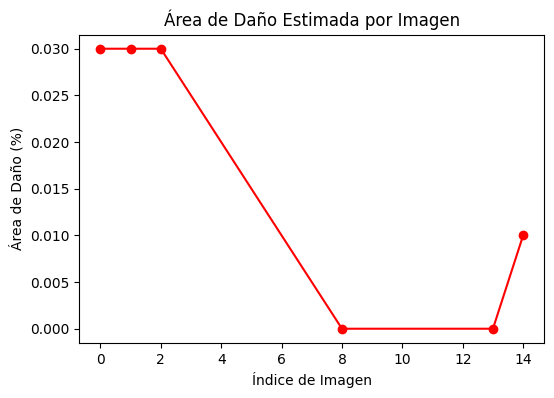

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Leer predicciones desde CSV
def load_predictions():
    try:
        df = pd.read_csv('/content/drive/My Drive/stacion/predictions.csv',
                         names=['image', 'result', 'confidence', 'damage_percent'])
        return df
    except FileNotFoundError:
        print("No hay predicciones aún. Sube imágenes en la web primero.")
        return pd.DataFrame()

# Gráfico 1: Conteo de daños vs no daños
def plot_damage_counts(df):
    counts = df['result'].value_counts()
    plt.figure(figsize=(6, 4))
    counts.plot(kind='bar', color=['red', 'green'])
    plt.title('Conteo de Predicciones: Daños vs Sin Daños')
    plt.xlabel('Resultado')
    plt.ylabel('Cantidad')
    plt.show()

# Gráfico 2: Histograma de confianza
def plot_confidence_histogram(df):
    plt.figure(figsize=(6, 4))
    df['confidence'].hist(bins=20, color='blue', alpha=0.7)
    plt.title('Distribución de Confianza en Predicciones')
    plt.xlabel('Confianza (%)')
    plt.ylabel('Frecuencia')
    plt.show()

# Gráfico 3: Área de daño promedio
def plot_damage_area(df):
    damaged = df[df['result'] == 'Daño detectado']
    if not damaged.empty:
        plt.figure(figsize=(6, 4))
        plt.plot(damaged.index, damaged['damage_percent'], 'ro-')
        plt.title('Área de Daño Estimada por Imagen')
        plt.xlabel('Índice de Imagen')
        plt.ylabel('Área de Daño (%)')
        plt.show()

# Ejecutar visualización
df = load_predictions()
if not df.empty:
    plot_damage_counts(df)
    plot_confidence_histogram(df)
    plot_damage_area(df)
else:
    print("Ejecuta la API y sube imágenes para generar gráficos.")

In [ ]:
!ls -R /content/drive/MyDrive/stacion/

/content/drive/MyDrive/stacion/:
app.py			       predictions.csv	train
modelo_paneles_solares2.keras  templates	validation
modelo_paneles_solares3.keras  test

/content/drive/MyDrive/stacion/templates:
index.html

/content/drive/MyDrive/stacion/test:
damaged  good

/content/drive/MyDrive/stacion/test/damaged:
imag10.png  imag2.png	imag49.png  imag68.png	  iss_0058.png	iss_0079.png
imag11.png  imag30.png	imag4.png   imag69.png	  iss_0059.png	iss_0080.png
imag12.png  imag31.png	imag50.png  imag6.png	  iss_0060.png	iss_0081.png
imag13.png  imag32.png	imag51.png  imag70.png	  iss_0061.png	iss_0082.png
imag14.png  imag33.png	imag52.png  imag71.png	  iss_0062.png	iss_0083.png
imag15.png  imag34.png	imag53.png  imag72.png	  iss_0063.png	iss_0084.png
imag16.png  imag35.png	imag54.png  imag7.png	  iss_0064.png	iss_0085.png
imag17.png  imag36.png	imag55.png  imag8.png	  iss_0065.png	iss_0086.png
imag18.png  imag37.png	imag56.png  imag9.png	  iss_0066.png	iss_0087.png
imag19.png  imag38.png	imag5

In [ ]:
from PIL import Image
import os

ruta = "/content/drive/MyDrive/stacion/validation/good"
salida = "/content/drive/MyDrive/stacion/validation/good"

os.makedirs(salida, exist_ok=True)

for nombre in os.listdir(ruta):
    if nombre.endswith(('.png', '.jpg', '.jpeg')):
        img = Image.open(os.path.join(ruta, nombre))
        ancho, alto = img.size
        # Recorta el panel central (ajusta proporciones según tus imágenes)
        # area = (ancho * 0.1, alto * 0.3, ancho * 0.9, alto * 0.7)
        area = (ancho * 0.1, alto * 0.15, ancho * 0.9, alto * 0.65)
        recortada = img.crop(area)
        recortada.save(os.path.join(salida, nombre))



3


In [ ]:
import random
import time


In [ ]:
%%writefile "/content/drive/My Drive/stacion/app2.py"
import tensorflow as tf
import numpy as np
from flask import Flask, request, render_template, jsonify
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import cv2
import os
import base64
from io import BytesIO
from PIL import Image
import random
import time

app = Flask(__name__)

# Cargar el modelo
model = tf.keras.models.load_model('/content/drive/My Drive/stacion/modelo_paneles_solares4.keras')

# Directorio para guardar imágenes temporales
UPLOAD_FOLDER = '/tmp/uploads'
os.makedirs(UPLOAD_FOLDER, exist_ok=True)

# Preprocesar imagen para la IA
def preprocess_image(image_path):
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

# Detectar y resaltar daño (áreas claras como agujeros)
def highlight_damage(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    total_area = img.shape[0] * img.shape[1]
    damage_area = sum(cv2.contourArea(c) for c in contours)
    damage_percent = (damage_area / total_area) * 100 if total_area > 0 else 0

    # Dibujar contornos rojos
    cv2.drawContours(img_rgb, contours, -1, (255, 0, 0), 2)

    # Guardar imagen resaltada
    highlighted_path = os.path.join(UPLOAD_FOLDER, 'highlighted.jpg')
    cv2.imwrite(highlighted_path, cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))

    # Convertir a base64 para mostrar en web
    with open(highlighted_path, "rb") as img_file:
        img_base64 = base64.b64encode(img_file.read()).decode('utf-8')

    return img_base64, damage_percent

@app.route('/')
def index():
    return render_template('index.html')

@app.route('/predict', methods=['POST'])
def predict():
    if 'image' not in request.files:
        return jsonify({'error': 'No se subió ninguna imagen'})

    file = request.files['image']
    image_path = os.path.join(UPLOAD_FOLDER, 'uploaded.jpg')
    file.save(image_path)

    # Predecir con el modelo
    processed_image = preprocess_image(image_path)
    prediction = model.predict(processed_image)[0][0]
    result = 'Daño detectado' if prediction > 0.5 else 'Sin daños'
    confidence = prediction * 100 if prediction > 0.5 else (1 - prediction) * 100

    # Resaltar daño si es detectado
    highlighted_image, damage_percent = None, 0
    if prediction > 0.5:
        highlighted_image, damage_percent = highlight_damage(image_path)

        # -----------------------------
        # Elegir acción de reparación al azar
        # -----------------------------
        acciones = ["limpiar", "parchar", "reemplazar", "ajustar_tornillos"]
        accion_seleccionada = random.choice(acciones)
        time.sleep(2)  # Simula tiempo de “pensamiento”
    else:
        accion_seleccionada = "N/A"

    # Guardar predicción en CSV
    with open('/content/drive/My Drive/stacion/predictions.csv', 'a') as f:
        f.write(f"{image_path},{result},{confidence:.2f},{damage_percent:.2f},{accion_seleccionada}\n")

    return jsonify({
        'result': result,
        'confidence': f"{confidence:.2f}%",
        'damage_percent': f"{damage_percent:.2f}%" if damage_percent > 0 else "N/A",
        'highlighted_image': highlighted_image,
        'accion_reparacion': accion_seleccionada
    })

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000, debug=True)


Writing /content/drive/My Drive/stacion/app2.py


In [1]:
# =====================================
# 🔧 Configuración inicial
# =====================================
# 1. Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Borrar configuraciones viejas de ngrok (importante)
!rm -rf /root/.ngrok2

# 3. Agregar tu nuevo token de ngrok
!ngrok config add-authtoken 33dI8FuPzwwNQOxi6bYksdcX8KK_2U3AbKc37x68XgFtsyM6p

# =====================================
# 🚀 Iniciar Flask + ngrok
# =====================================
from pyngrok import ngrok
import os
import time

# Cerrar túneles previos
ngrok.kill()

# Conectar al puerto 5000
public_url = ngrok.connect(5000)
print("🌐 Tu app está disponible en:", public_url)

# 4. Ejecutar tu aplicación Flask (ajusta la ruta si es distinta)
os.system('python "/content/drive/My Drive/stacion/app2.py" &')

# Mantener la sesión activa
while True:
    time.sleep(10)


Mounted at /content/drive
/bin/bash: line 1: ngrok: command not found


ModuleNotFoundError: No module named 'pyngrok'

In [ ]:
!pip install pyngrok --quiet
!command -v ngrok >/dev/null 2>&1 || { curl -s https://ngrok-agent.s3.amazonaws.com/ngrok.asc | sudo tee /etc/apt/trusted.gpg.d/ngrok.asc >/dev/null && echo "deb https://ngrok-agent.s3.amazonaws.com focal main" | sudo tee /etc/apt/sources.list.d/ngrok.list && sudo apt-get update && sudo apt-get install ngrok -y; }